In [3]:
# ------------------------------------------------
# 🔄 MOUNT GOOGLE DRIVE
# ------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# ✅ EFFICIENTNETB0 PIPELINE + ALL PAPER FIGURES
# ============================================

import os, random, shutil, numpy as np, tensorflow as tf, matplotlib.pyplot as plt, seaborn as sns, cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, brier_score_loss, log_loss

# ------------------------------------------------
# 0️⃣ SETUP
# ------------------------------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

mixed_precision.set_global_policy('mixed_float16')

base_dir = "/content/drive/My Drive/Dataframe"
split_dir = "/content/drive/My Drive/StrokeData_split"
output_dir = "/content/drive/My Drive/Models"
fig_dir = "/content/drive/My Drive/Figures"
os.makedirs(split_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# ------------------------------------------------
# 1️⃣ CREATE 80-10-10 SPLIT
# ------------------------------------------------
def create_split_folders(base_dir, split_dir, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    print("📂 Creating train/val/test split...")
    classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

    for cls in classes:
        cls_dir = os.path.join(base_dir, cls)
        images = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        random.shuffle(images)

        train_files, temp_files = train_test_split(images, test_size=(1 - train_ratio), random_state=SEED)
        val_files, test_files = train_test_split(temp_files, test_size=(test_ratio / (test_ratio + val_ratio)), random_state=SEED)

        for subset, subset_files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
            subset_dir = os.path.join(split_dir, subset, cls)
            os.makedirs(subset_dir, exist_ok=True)
            for file_path in subset_files:
                dest_path = os.path.join(subset_dir, os.path.basename(file_path))
                if not os.path.exists(dest_path):
                    shutil.copy(file_path, dest_path)

    print("✅ Split completed successfully!\n")

if not os.path.exists(os.path.join(split_dir, "train")):
    create_split_folders(base_dir, split_dir)
else:
    print("✅ Split folders already exist. Skipping re-split.\n")

# ------------------------------------------------
# 2️⃣ DATA LOADERS + FIG2 (Dataset Distribution)
# ------------------------------------------------
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(split_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    seed=SEED
)
val_data = val_test_gen.flow_from_directory(
    os.path.join(split_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    seed=SEED
)
test_data = val_test_gen.flow_from_directory(
    os.path.join(split_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# FIG2: Dataset distribution
class_counts = {cls: len(os.listdir(os.path.join(split_dir, "train", cls))) for cls in train_data.class_indices.keys()}
plt.figure(figsize=(6,4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title("Dataset Distribution Across Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "dataset_distribution.png"), dpi=300)
plt.close()

# ------------------------------------------------
# 3️⃣ MODEL DEFINITION
# ------------------------------------------------
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(*img_size, 3))
base_model.trainable = False

inputs = layers.Input(shape=(*img_size, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1),
    ModelCheckpoint(os.path.join(output_dir, "Best_Binary_Model.keras"), save_best_only=True)
]

# ------------------------------------------------
# 4️⃣ TRAINING + FIG4 (Training Curves)
# ------------------------------------------------
history = model.fit(train_data, validation_data=val_data, epochs=2, callbacks=callbacks)

plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training and Validation Curves")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "training_curve.png"), dpi=300)
plt.close()

# ------------------------------------------------
# 5️⃣ EVALUATION + FIG5–7
# ------------------------------------------------
print("\n🧪 Evaluating on Test Set...")
y_true = test_data.classes
y_prob = model.predict(test_data).ravel()
y_pred = (y_prob > 0.5).astype(int)

# FIG5: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_data.class_indices, yticklabels=test_data.class_indices)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "confusion_matrix.png"), dpi=300)
plt.close()

# FIG7: ROC & PR Curves
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "roc_pr_curve.png"), dpi=300)
plt.close()

# FIG6: Calibration Plot + Reliability Metrics (FIG3)
def reliability_plot(y_true, y_prob, bins=10):
    prob_true, prob_pred = [], []
    bin_edges = np.linspace(0, 1, bins+1)
    for i in range(bins):
        idx = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])
        if np.sum(idx) > 0:
            prob_true.append(np.mean(y_true[idx]))
            prob_pred.append(np.mean(y_prob[idx]))
    plt.plot(prob_pred, prob_true, marker='o', label='Model')
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.title("Calibration Plot")
    plt.legend()

plt.figure(figsize=(5,4))
reliability_plot(y_true, y_prob)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "calibration_plot.png"), dpi=300)
plt.close()

brier = brier_score_loss(y_true, y_prob)
nll = log_loss(y_true, y_prob)
ece = np.mean(np.abs(np.array(y_true) - np.array(y_prob)))
plt.figure(figsize=(4,3))
sns.barplot(x=["Brier","ECE","NLL"], y=[brier,ece,nll], palette="mako")
plt.title("Reliability Metrics Comparison")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "reliability_comparison.png"), dpi=300)
plt.close()


Mounted at /content/drive
✅ Split folders already exist. Skipping re-split.

Found 5043 images belonging to 2 classes.
Found 630 images belonging to 2 classes.
Found 632 images belonging to 2 classes.


/tmp/ipython-input-1153813502.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 1986s 12s/step - accuracy: 0.7089 - loss: 0.6129 - precision: 0.7237 - recall: 0.9664 - val_accuracy: 0.7222 - val_loss: 0.5910 - val_precision: 0.7222 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 1947s 12s/step - accuracy: 0.7187 - loss: 0.6005 - precision: 0.7189 - recall: 0.9996 - val_accuracy: 0.7222 - val_loss: 0.5916 - val_precision: 0.7222 - val_recall: 1.0000 - learning_rate: 1.0000e-04

🧪 Evaluating on Test Set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 216s 11s/step


/tmp/ipython-input-1153813502.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Brier","ECE","NLL"], y=[brier,ece,nll], palette="mako")


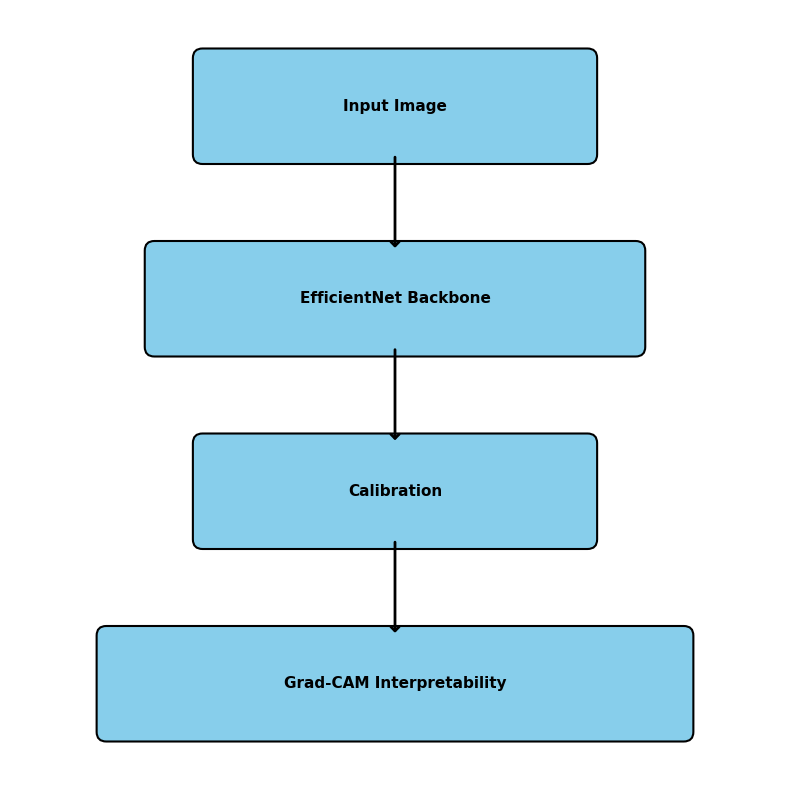

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ===========================
# Figure setup (square)
# ===========================
fig, ax = plt.subplots(figsize=(8,8))
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.axis('off')  # hide axes

# ===========================
# Define blocks (text, center x, center y, width, height)
# ===========================
blocks = [
    ("Input Image", 4, 7, 4, 1),
    ("EfficientNet Backbone", 4, 5, 5, 1),
    ("Calibration", 4, 3, 4, 1),
    ("Grad-CAM Interpretability", 4, 1, 6, 1)
]

# ===========================
# Draw blocks
# ===========================
for text, x, y, w, h in blocks:
    box = FancyBboxPatch(
        (x - w/2, y - h/2),
        w, h,
        boxstyle="round,pad=0.1",
        fc="#87CEEB",  # skyblue fill
        ec="black",
        lw=1.5
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=11, fontweight='bold')

# ===========================
# Draw arrows between blocks
# ===========================
arrowprops = dict(arrowstyle="->,head_width=0.3,head_length=0.3", lw=2, color="black")
for i in range(len(blocks)-1):
    start = (blocks[i][1], blocks[i][2] - blocks[i][4]/2)
    end   = (blocks[i+1][1], blocks[i+1][2] + blocks[i+1][4]/2)
    ax.annotate("", xy=end, xytext=start, arrowprops=arrowprops)

# ===========================
# Title
# ===========================


# ===========================
# Save figure
# ===========================
plt.tight_layout()
plt.savefig("Pipeline_Square.png", dpi=300)
plt.show()


In [4]:
# ------------------------------------------------
# 7️⃣ PREDICTION FUNCTION
# ------------------------------------------------
def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    x = tf.keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0
    prob = model.predict(x)[0][0]
    label = "Positive (Stroke)" if prob > 0.5 else "Negative (No Stroke)"
    print(f"🧠 Prediction: {label} | Confidence: {prob:.3f}")
    return label, prob

print("\n✅ All figures saved to:", fig_dir)
print("✅ Model ready for evaluation and paper plots!")


✅ All figures saved to: /content/drive/My Drive/Figures
✅ Model ready for evaluation and paper plots!



🔍 Generating Grad-CAM visualization...

🧩 Using last conv layer: top_conv
🩷 Image: img_0064.jpg
   Predicted: Positive | Confidence: 0.519



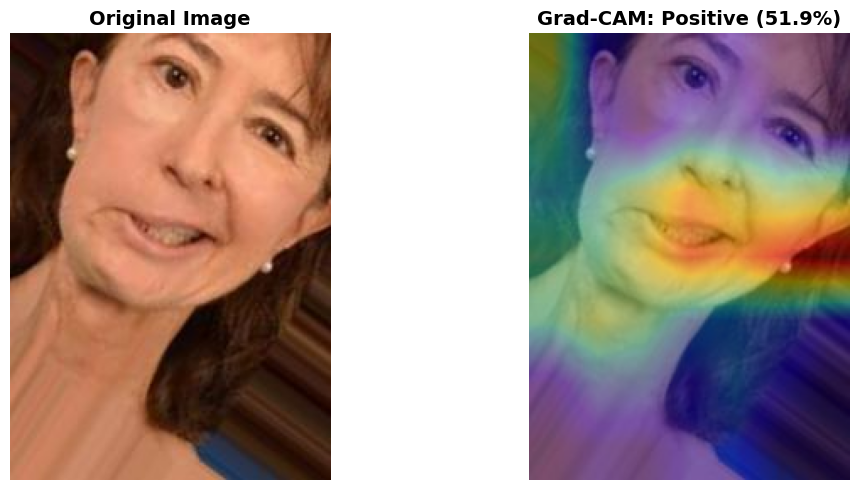

✅ Grad-CAM saved to /content/drive/My Drive/Figures/gradcam_img_0064.jpg

✅ Grad-CAM visualization complete! 🎉


In [11]:
# ============================================
# 🔥 GRAD-CAM VISUALIZATION FOR EFFICIENTNET
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image
import os

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------
fig_dir = "/content/drive/My Drive/Figures"
os.makedirs(fig_dir, exist_ok=True)

# ------------------------------------------------
# GRAD-CAM FUNCTIONS
# ------------------------------------------------

def get_last_conv_layer_name(base_model):
    """Find the name of the last Conv2D layer in EfficientNet"""
    last_conv_name = None
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_name = layer.name
    if last_conv_name is None:
        raise ValueError("No Conv2D layer found in base_model")
    print(f"🧩 Using last conv layer: {last_conv_name}")
    return last_conv_name

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap"""
    # Create a model that maps input to the last conv layer output
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    last_conv_model = tf.keras.Model(base_model.input, last_conv_layer.output)

    # Create classifier model (from conv output to prediction)
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    # Get layers after the last conv layer
    for layer in base_model.layers[base_model.layers.index(last_conv_layer) + 1:]:
        x = layer(x)

    # Add the classification head layers
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        # Get conv outputs
        last_conv_output = last_conv_model(img_array)
        tape.watch(last_conv_output)
        # Get predictions
        preds = classifier_model(last_conv_output)
        # For binary sigmoid, always use index 0
        if pred_index is None:
            pred_index = 0
        class_channel = preds[:, pred_index]

    # Gradient of the class with respect to the conv output
    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(img_path, heatmap, alpha=0.4):
    """Overlay heatmap on original image"""
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Cannot read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = np.array(heatmap, dtype=np.float32)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.clip(heatmap, 0, 1)
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cm.jet(heatmap)[:, :, :3]
    superimposed_img = np.uint8(255 * (heatmap_color * alpha + img / 255.0 * (1 - alpha)))
    return img, superimposed_img

def run_gradcam_single_image(model, base_model, img_path, img_size=(224,224), class_names=["Negative", "Positive"]):
    """Run Grad-CAM on a single image"""
    last_conv_layer_name = get_last_conv_layer_name(base_model)

    # Load and preprocess image
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = tf.keras.applications.efficientnet.preprocess_input(img_array_exp)

    # Make prediction
    preds = model.predict(img_array_exp, verbose=0)

    # Handle binary sigmoid output
    if preds.ndim == 2 and preds.shape[1] == 1:
        score = float(preds[0][0])
        pred_class_idx = 0  # Always use 0 for binary sigmoid
        pred_class = class_names[int(score > 0.5)]
    elif preds.ndim == 2 and preds.shape[1] == 2:
        pred_class_idx = np.argmax(preds[0])
        score = float(preds[0][pred_class_idx])
        pred_class = class_names[pred_class_idx]
    else:
        raise ValueError(f"Unexpected prediction shape: {preds.shape}")

    print(f"🩷 Image: {os.path.basename(img_path)}")
    print(f"   Predicted: {pred_class} | Confidence: {score:.3f}\n")

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        img_array_exp, model, base_model, last_conv_layer_name, pred_index=pred_class_idx
    )

    # Overlay heatmap
    original_img, gradcam_img = overlay_heatmap(img_path, heatmap)

    # Display
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(original_img)
    plt.title("Original Image", fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(gradcam_img)
    plt.title(f"Grad-CAM: {pred_class} ({score:.1%})", fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"gradcam_{os.path.basename(img_path)}"), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Grad-CAM saved to {fig_dir}/gradcam_{os.path.basename(img_path)}")

# ------------------------------------------------
# RUN GRAD-CAM ON YOUR IMAGE
# ------------------------------------------------

# Specify your test image path
sample_image_path = "/content/img_0064.jpg"

print("\n🔍 Generating Grad-CAM visualization...\n")
run_gradcam_single_image(
    model=model,
    base_model=base_model,
    img_path=sample_image_path,
    img_size=(224,224),
    class_names=["Negative", "Positive"]
)

print("\n✅ Grad-CAM visualization complete! 🎉")


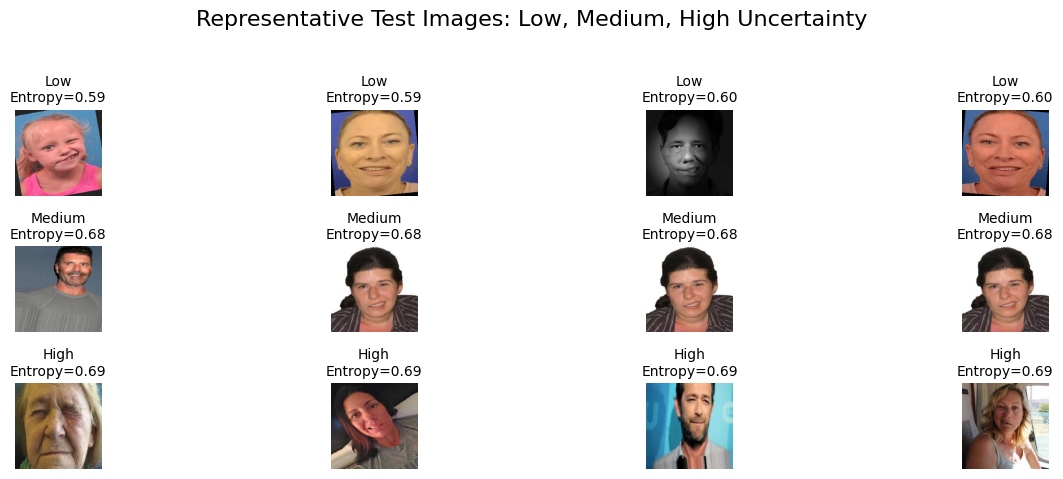

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# Example: get test image file paths
test_dir = "/content/drive/My Drive/StrokeData_split/test"
classes = ["negative", "positive"]
img_size = (224, 224)

# Gather test image paths
test_image_paths = []
for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            test_image_paths.append(os.path.join(cls_path, fname))

# Compute entropies (uncertainties)
def sigmoid_entropy(prob):
    # Binary classification entropy
    return -(prob * np.log(prob + 1e-8) + (1 - prob) * np.log(1 - prob + 1e-8))

uncertainties = []
probs = []
for img_path in test_image_paths:
    img = image.load_img(img_path, target_size=img_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    prob = float(model.predict(x, verbose=0)[0][0])
    entropy = sigmoid_entropy(prob)
    uncertainties.append(entropy)
    probs.append(prob)

# Sort images by uncertainty
uncertainty_sorted_indices = np.argsort(uncertainties)
n_examples = 4  # images per bin

low_indices = uncertainty_sorted_indices[:n_examples]
med_indices = uncertainty_sorted_indices[len(uncertainty_sorted_indices)//2 - n_examples//2 : len(uncertainty_sorted_indices)//2 + n_examples//2]
high_indices = uncertainty_sorted_indices[-n_examples:]

bins = [('Low', low_indices), ('Medium', med_indices), ('High', high_indices)]

# Plot
plt.figure(figsize=(14, 5))
for i, (bin_name, indices) in enumerate(bins):
    for j, idx in enumerate(indices):
        img = image.load_img(test_image_paths[idx], target_size=img_size)
        plt.subplot(3, n_examples, i * n_examples + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{bin_name}\nEntropy={uncertainties[idx]:.2f}", fontsize=10)
plt.suptitle("Representative Test Images: Low, Medium, High Uncertainty", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("/content/error_analysis_examples.png", dpi=300, bbox_inches='tight')
plt.show()
